### Problem Description

The goal is to predict the `Hourly Electrical Energy output (MW)` of a power plant based on various ambient conditions. This is a regression problem where we aim to build a model that can accurately estimate the electrical power output given input features related to the environment.

### Dataset Features Summary

The dataset contains the following features collected from a Combined Cycle Power Plant over 6 years (2006-2011) when the plant was set to work with a full load. The dataset consists of hourly average ambient variables:

*   **`Ambient Temperature (C)`**: The temperature of the surrounding environment in Celsius.
*   **`Exhaust Vacuum (cm Hg)`**: The exhaust vacuum pressure in centimeters of mercury.
*   **`Ambient Pressure (milibar)`**: The atmospheric pressure in millibars.
*   **`Relative Humidity (%)`**: The percentage of relative humidity in the air.
*   **`Hourly Electrical Energy output (MW)`**: This is the target variable, representing the electrical power produced by the plant in megawatts per hour.

In [61]:
import numpy as np  # for doing numerical operations
import pandas as pd  # for data analysis
import matplotlib.pyplot as plt  # for data visualization
import seaborn as sns  # for data visualization

In [62]:
dataset = pd.read_csv('Power Plant Data.csv')

In [63]:
# Set the float format to 2 decimal
pd.options.display.float_format = '{:.2f}'.format

# Display the first few rows as sample
dataset.head()

,Ambient Temperature (C),Exhaust Vacuum (cm Hg),Ambient Pressure (milibar),Relative Humidity (%),Hourly Electrical Energy output (MW)
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [64]:
# Base properties of dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Ambient Temperature (C)               9568 non-null   float64
 1   Exhaust Vacuum (cm Hg)                9568 non-null   float64
 2   Ambient Pressure (milibar)            9568 non-null   float64
 3   Relative Humidity (%)                 9568 non-null   float64
 4   Hourly Electrical Energy output (MW)  9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [65]:
# Statistic properties of numerical values
dataset.describe()

,Ambient Temperature (C),Exhaust Vacuum (cm Hg),Ambient Pressure (milibar),Relative Humidity (%),Hourly Electrical Energy output (MW)
count,9568.00,9568.00,9568.00,9568.00,9568.00
mean,19.65,54.31,1013.26,73.31,454.37
std,7.45,12.71,5.94,14.60,17.07
min,1.81,25.36,992.89,25.56,420.26
25%,13.51,41.74,1009.10,63.33,439.75
50%,20.34,52.08,1012.94,74.97,451.55
75%,25.72,66.54,1017.26,84.83,468.43
max,37.11,81.56,1033.30,100.16,495.76


Data exists in an acceptable format. Min and max are both reasonable values, showing there were no dramatically irregular data points.

In [66]:
print('Missing values in each column:')
display(dataset.isnull().sum())

Missing values in each column:


,0
Ambient Temperature (C),0
Exhaust Vacuum (cm Hg),0
Ambient Pressure (milibar),0
Relative Humidity (%),0
Hourly Electrical Energy output (MW),0


The test above shows there are zero missing data points in any column. We can proceed with analysis since the dataset is suitable.

In [67]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

First, split the data for 80% training and 20% testing

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np # Needed for np.sqrt

# Define features (X) and target (y)
X = dataset.drop('Hourly Electrical Energy output (MW)', axis=1)
y = dataset['Hourly Electrical Energy output (MW)']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Feature Scaling to X
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

# Apply Feature Scaling to y
sc_y = StandardScaler()
y_train = y_train.values.reshape(len(y_train), 1) # Reshape y_train for StandardScaler
y_train = sc_y.fit_transform(y_train)

y_test = y_test.values.reshape(len(y_test), 1)   # Reshape y_test for StandardScaler
y_test = sc_y.transform(y_test)

# --- Linear Regression Model Training and Evaluation ---
regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Linear Regression R-squared: {r2:.4f}")
print(f"Linear Regression Mean Absolute Error (MAE): {mae:.4f}")
print(f"Linear Regression Mean Squared Error (MSE): {mse:.4f}")
print(f"Linear Regression Root Mean Squared Error (RMSE): {rmse:.4f}")


Linear Regression R-squared: 0.9301
Linear Regression Mean Absolute Error (MAE): 0.2106
Linear Regression Mean Squared Error (MSE): 0.0695
Linear Regression Root Mean Squared Error (RMSE): 0.2637


Now applying a **Linear Regression Model**

In [69]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_new=regressor.predict(X_train)

# Fix: Flatten y_train and y_new to create a 2D DataFrame for comparison
compare_df = pd.DataFrame({
    'Actual (y_train)': y_train.flatten(),
    'Predicted (y_new)': y_new.flatten()
})
display(compare_df.head())

,Actual (y_train),Predicted (y_new)
0,-0.65,-0.35
1,2.14,1.21
2,1.73,1.39
3,0.98,1.00
4,0.52,0.44


### Visualizing Linear Regression Model Predictions vs. Actual Values on the Test Set

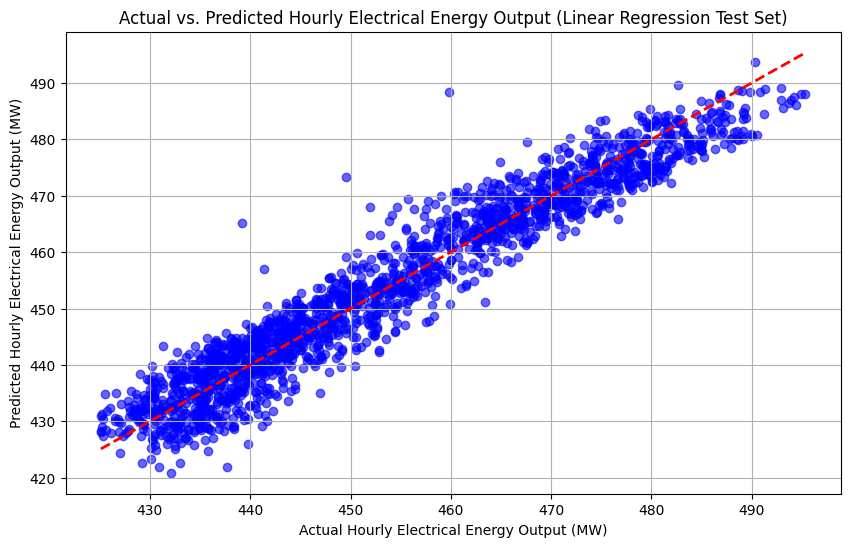

In [70]:
# Inverse transform y_test and y_pred to original scale for visualization
y_test_orig = sc_y.inverse_transform(y_test)
y_pred_orig = sc_y.inverse_transform(y_pred)

plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, y_pred_orig, color='blue', alpha=0.6)
plt.plot([min(y_test_orig), max(y_test_orig)], [min(y_test_orig), max(y_test_orig)], color='red', linestyle='--', linewidth=2)
plt.title('Actual vs. Predicted Hourly Electrical Energy Output (Linear Regression Test Set)')
plt.xlabel('Actual Hourly Electrical Energy Output (MW)')
plt.ylabel('Predicted Hourly Electrical Energy Output (MW)')
plt.grid(True)
plt.show()

### Predictive Model with Support Vector Regression (SVR)

In [71]:
from sklearn.svm import SVR

# Create an SVR regressor object
# We'll use a radial basis function (RBF) kernel as it's common for non-linear relationships
sup_regressor = SVR(kernel = 'rbf')

# Train the SVR model on the scaled training data
# y_train needs to be flattened for SVR's fit method if it's a 2D array with one column
sup_regressor.fit(X_train, y_train.ravel())

# Make predictions on the scaled test set
y_pred_svr = sup_regressor.predict(X_test)

In [72]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Calculate performance metrics for SVR
r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print(f"SVR R-squared: {r2_svr:.4f}")
print(f"SVR Mean Absolute Error (MAE): {mae_svr:.4f}")
print(f"SVR Mean Squared Error (MSE): {mse_svr:.4f}")
print(f"SVR Root Mean Squared Error (RMSE): {rmse_svr:.4f}")

SVR R-squared: 0.9468
SVR Mean Absolute Error (MAE): 0.1761
SVR Mean Squared Error (MSE): 0.0529
SVR Root Mean Squared Error (RMSE): 0.2300


### Visualizing SVR Model Predictions vs. Actual Values on the Test Set

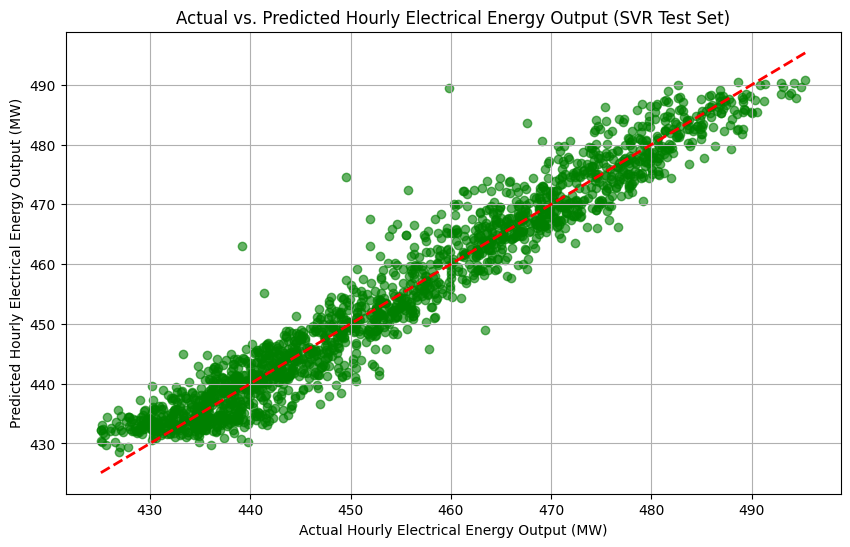

In [73]:
# Inverse transform y_test and y_pred_svr to original scale for visualization
y_test_orig_svr = sc_y.inverse_transform(y_test)
y_pred_orig_svr = sc_y.inverse_transform(y_pred_svr.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig_svr, y_pred_orig_svr, color='green', alpha=0.6)
plt.plot([min(y_test_orig_svr), max(y_test_orig_svr)], [min(y_test_orig_svr), max(y_test_orig_svr)], color='red', linestyle='--', linewidth=2)
plt.title('Actual vs. Predicted Hourly Electrical Energy Output (SVR Test Set)')
plt.xlabel('Actual Hourly Electrical Energy Output (MW)')
plt.ylabel('Predicted Hourly Electrical Energy Output (MW)')
plt.grid(True)
plt.show()

### Visual Comparison: Linear Regression vs. SVR Predictions

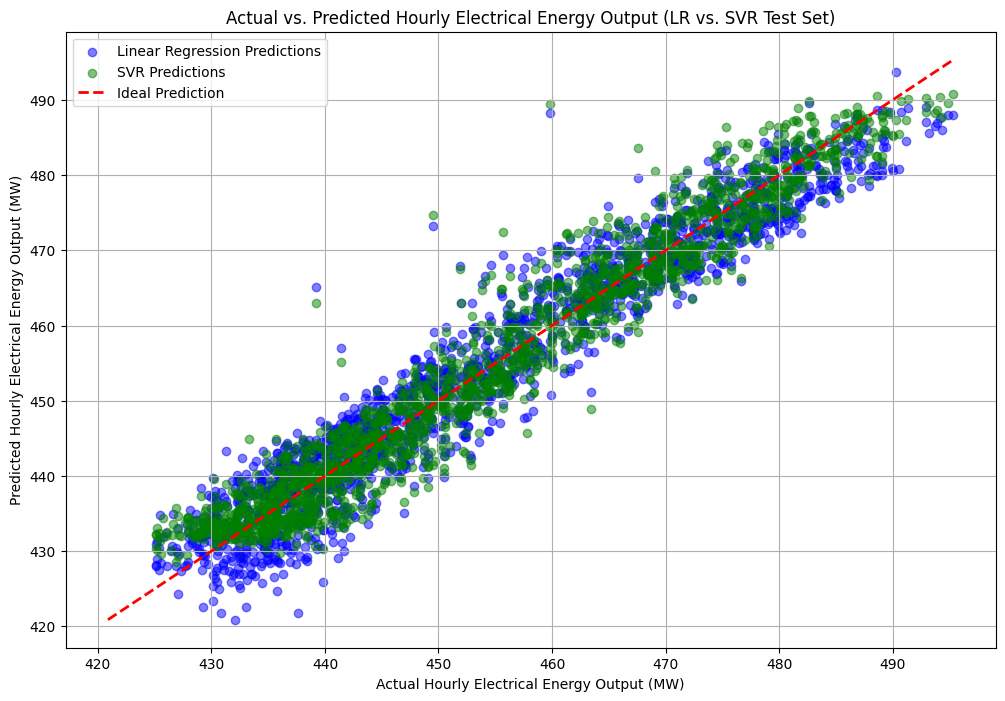

In [74]:
# Inverse transform y_test, y_pred (LR), and y_pred_svr to original scale for visualization
# y_test_orig, y_pred_orig are already available from the LR plotting section
# y_test_orig_svr, y_pred_orig_svr are already available from the SVR plotting section

plt.figure(figsize=(12, 8))

# Plot Linear Regression predictions
plt.scatter(y_test_orig, y_pred_orig, color='blue', alpha=0.5, label='Linear Regression Predictions')

# Plot SVR predictions
plt.scatter(y_test_orig_svr, y_pred_orig_svr, color='green', alpha=0.5, label='SVR Predictions')

# Plot the ideal prediction line
min_val = min(min(y_test_orig), min(y_pred_orig), min(y_pred_orig_svr))
max_val = max(max(y_test_orig), max(y_pred_orig), max(y_pred_orig_svr))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction')

plt.title('Actual vs. Predicted Hourly Electrical Energy Output (LR vs. SVR Test Set)')
plt.xlabel('Actual Hourly Electrical Energy Output (MW)')
plt.ylabel('Predicted Hourly Electrical Energy Output (MW)')
plt.legend()
plt.grid(True)
plt.show()

### Model Comparison:

Comparing the two models, the SVR model performed slightly better than the Linear Regression model, achieving a higher R-squared (0.9468 vs. 0.9301) and lower error metrics (MAE, MSE, RMSE). This suggests that there might be some non-linear relationships in the data that the SVR with an RBF kernel was able to capture more effectively than the linear model.

Both models demonstrate strong predictive capabilities for the hourly electrical energy output. The choice between them would depend on factors like interpretability needs, computational cost, and further fine-tuning potential.